In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [4]:
# 1. Lire le premier fichier (ex: Profil des employés)
# Remplacez 'employes.xlsx' par le nom réel de votre fichier
df_empl = pd.read_excel('/content/dimemploye.xlsx')

# 2. Lire le deuxième fichier (ex: Performance/Satisfaction)
df_perf = pd.read_excel('/content/factperfo.xlsx')

# 3. Afficher les 5 premières lignes pour vérifier le chargement
print("--- Aperçu du tableau Employés ---")
print(df_empl.head())

print("\n--- Aperçu du tableau Performance ---")
print(df_perf.head())

--- Aperçu du tableau Employés ---
  EmployeeID FirstName  LastName      Gender  Age      BusinessTravel  \
0  C08F-94F9     Nikos  Karpenko        Male   26         Some Travel   
1  ADF8-AD57      Trip   Bennell        Male   27         Some Travel   
2  8766-F1E7  Jonathon     Lovie        Male   25         Some Travel   
3  4188-C61D     Fanny     Yoell      Female   22           No Travel   
4  7823-0217  Germaine   Clubley  Non-Binary   25  Frequent Traveller   

   Department  DistanceFromHome (KM) State Ethnicity  ...  StockOptionLevel  \
0  Technology                     32    NY     White  ...                 0   
1  Technology                     28    CA     White  ...                 0   
2  Technology                     18    CA     White  ...                 0   
3  Technology                     27    CA     White  ...                 0   
4       Sales                     43    CA     White  ...                 0   

  OverTime   HireDate Attrition  YearsAtCompany  Ye

In [6]:
# 2. Fusion des tableaux sur la colonne commune 'EmployeeID'
# On utilise 'inner' pour ne garder que les employés présents dans les deux fichiers
df_complet = pd.merge(df_empl, df_perf, on='EmployeeID', how='inner')

# 3. Création du nouveau tableau avec uniquement vos colonnes cibles
colonnes_selectionnees = [
    'EmployeeID',
    'Attrition',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

# Nouveau DataFrame filtré
df_analyse = df_complet[colonnes_selectionnees].copy()

# 4. Vérification du résultat
print(df_analyse.head())

  EmployeeID Attrition  EnvironmentSatisfaction  JobSatisfaction  \
0  C08F-94F9       Yes                        3                4   
1  C08F-94F9       Yes                        3                5   
2  C08F-94F9       Yes                        3                4   
3  C08F-94F9       Yes                        3                4   
4  C08F-94F9       Yes                        4                4   

   RelationshipSatisfaction  WorkLifeBalance  
0                         2                3  
1                         4                3  
2                         4                4  
3                         5                4  
4                         4                3  


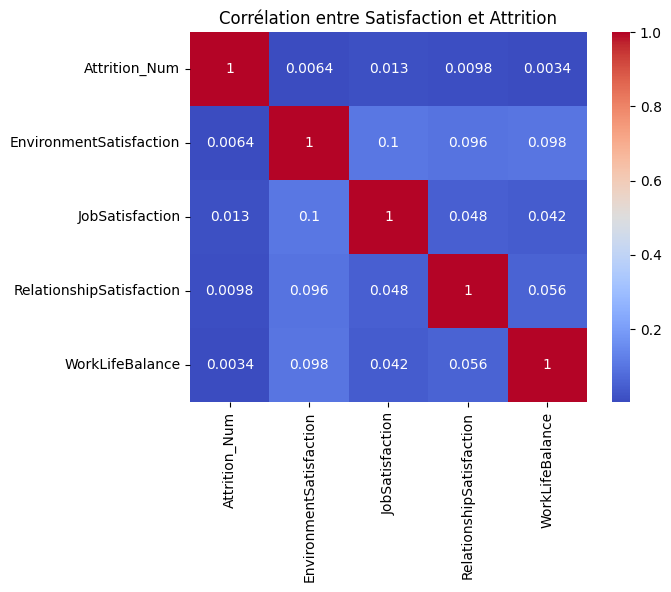

In [9]:
# 1. Convertir l'attrition en numérique (Yes=1, No=0)
df_analyse['Attrition_Num'] = df_analyse['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Matrice de corrélation ciblée
cols = ['Attrition_Num', 'EnvironmentSatisfaction', 'JobSatisfaction',
        'RelationshipSatisfaction', 'WorkLifeBalance']
correlation_matrix = df_analyse[cols].corr()

# 3. Visualisation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation entre Satisfaction et Attrition")
plt.show()

In [10]:
# 2. Transformation de la cible (Attrition) en binaire : Yes=1, No=0
df_analyse['Attrition'] = df_analyse['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Sélection des variables de satisfaction et de l'équilibre vie pro/perso
features = ['EnvironmentSatisfaction', 'JobSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance']
X = df_analyse[features]
y = df_analyse['Attrition']

# 4. Division en set d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Création et entraînement du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.94      0.78       892
           1       0.38      0.07      0.12       450

    accuracy                           0.65      1342
   macro avg       0.53      0.51      0.45      1342
weighted avg       0.57      0.65      0.56      1342



/tmp/ipykernel_8499/2141269461.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


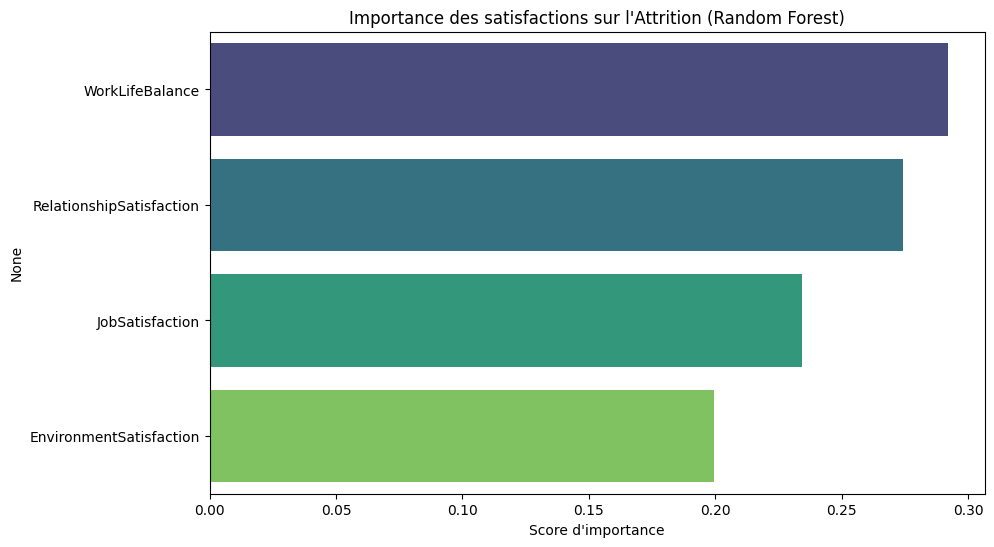

In [12]:
# Extraction de l'importance des variables
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

# Graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Importance des satisfactions sur l'Attrition (Random Forest)")
plt.xlabel("Score d'importance")
plt.show()